In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Tidy data

In this example we'll do some relatively simple data cleaning. This will involve both melting and pivoting, as well as some string methods. 

In [2]:
birdflu = pd.read_table("bffixed.txt", sep = "\t")
birdflu.head()

,Country,2003cases,2003deaths,2004cases,2004deaths,2005cases,2005deaths,2006cases,2006deaths,2007cases,2007deaths,2008cases,2008deaths
0,Azerbaijan,0,0,0,0,0,0,8,5,0,0,0,0
1,Bangladesh,0,0,0,0,0,0,0,0,0,0,1,0
2,Cambodia,0,0,0,0,4,4,2,2,1,1,0,0
3,China,1,1,0,0,8,5,13,8,5,3,3,3
4,Djibouti,0,0,0,0,0,0,1,0,0,0,0,0


In [3]:
len(birdflu)

15

**What issues are we dealing with here?**

In [4]:
birdflu.columns[1:birdflu.shape[1]]

Index(['2003cases', '2003deaths', '2004cases', '2004deaths', '2005cases',
       '2005deaths', '2006cases', '2006deaths', '2007cases', '2007deaths',
       '2008cases', '2008deaths'],
      dtype='object')

In [6]:
help(pd.DataFrame.melt)

Help on function melt in module pandas.core.frame:

melt(
    self,
    id_vars=None,
    value_vars=None,
    var_name=None,
    value_name: 'Hashable' = 'value',
    col_level: 'Level | None' = None,
    ignore_index: 'bool' = True
) -> 'DataFrame'
    Unpivot a DataFrame from wide to long format, optionally leaving identifiers set.

    This function is useful to massage a DataFrame into a format where one
    or more columns are identifier variables (`id_vars`), while all other
    columns, considered measured variables (`value_vars`), are "unpivoted" to
    the row axis, leaving just two non-identifier columns, 'variable' and
    'value'.

    Parameters
    ----------
    id_vars : scalar, tuple, list, or ndarray, optional
        Column(s) to use as identifier variables.
    value_vars : scalar, tuple, list, or ndarray, optional
        Column(s) to unpivot. If not specified, uses all columns that
        are not set as `id_vars`.
    var_name : scalar, default None
        Name

In [14]:
# Go longer, specifying "Country" as our index
bf_long = birdflu.melt(id_vars = "Country",
            # The name of the new column for our new variable
            var_name = "year", 
            # The columns that contain the values we wish to melt
            value_vars = birdflu.columns[1:birdflu.shape[1]],
            # The name of the new column contains the melted values
            value_name = "Count")

bf_long

,Country,year,Count
0,Azerbaijan,2003cases,0
1,Bangladesh,2003cases,0
2,Cambodia,2003cases,0
3,China,2003cases,1
4,Djibouti,2003cases,0
...,...,...,...
175,Nigeria,2008deaths,0
176,Pakistan,2008deaths,0
177,Thailand,2008deaths,0
178,Turkey,2008deaths,0


In [15]:
len(bf_long)

180

**Are there still problems with the data?**

In [16]:
bf_long["year"].str.slice(start=4)

0       cases
1       cases
2       cases
3       cases
4       cases
        ...  
175    deaths
176    deaths
177    deaths
178    deaths
179    deaths
Name: year, Length: 180, dtype: object

In [17]:
bf_long["year"]

0       2003cases
1       2003cases
2       2003cases
3       2003cases
4       2003cases
          ...    
175    2008deaths
176    2008deaths
177    2008deaths
178    2008deaths
179    2008deaths
Name: year, Length: 180, dtype: object

In [18]:
# Use string methods
bf_long['count_type'] = bf_long["year"].str.slice(start=4)
bf_long["year"] = bf_long["year"].str.slice(stop=4)
bf_long.head()

,Country,year,Count,count_type
0,Azerbaijan,2003,0,cases
1,Bangladesh,2003,0,cases
2,Cambodia,2003,0,cases
3,China,2003,1,cases
4,Djibouti,2003,0,cases


**Are we there yet?**

In [19]:
# Pivot wider, specifying year and country to remain as the index (not to be aggregated)
bf_tidy = bf_long.pivot_table(index = ["year","Country"],
                              # Which column to populate new column values with
                              values = "Count", 
                              # Which column values to turn into new columns
                              columns = "count_type")
bf_tidy

count_type       cases  deaths
year Country                  
2003 Azerbaijan    0.0     0.0
     Bangladesh    0.0     0.0
     Cambodia      0.0     0.0
     China         1.0     1.0
     Djibouti      0.0     0.0
...                ...     ...
2008 Nigeria       0.0     0.0
     Pakistan      0.0     0.0
     Thailand      0.0     0.0
     Turkey        0.0     0.0
     VietNam       5.0     5.0

[90 rows x 2 columns]

In [20]:
# Use reset_index() to remove the multi-index
bf_tidy = bf_tidy.reset_index()
bf_tidy.head()

count_type,year,Country,cases,deaths
0,2003,Azerbaijan,0.0,0.0
1,2003,Bangladesh,0.0,0.0
2,2003,Cambodia,0.0,0.0
3,2003,China,1.0,1.0
4,2003,Djibouti,0.0,0.0


Finish cleaning up and remove the residual, misleading index name. 

In [21]:
bf_tidy = bf_tidy.rename_axis(None, axis=1)
bf_tidy

,year,Country,cases,deaths
0,2003,Azerbaijan,0.0,0.0
1,2003,Bangladesh,0.0,0.0
2,2003,Cambodia,0.0,0.0
3,2003,China,1.0,1.0
4,2003,Djibouti,0.0,0.0
...,...,...,...,...
85,2008,Nigeria,0.0,0.0
86,2008,Pakistan,0.0,0.0
87,2008,Thailand,0.0,0.0
88,2008,Turkey,0.0,0.0


## Relational data

We have a series of relational datasets representing E-commerce in Brazil. 

**Our goal is to connect customer ids with the products they ordered. Which of the datasets do we need?**

<img src="relations.png" width="800" align="center"/>

In [24]:
customers = pd.read_csv("./brazil_commerce/olist_customers_dataset.csv")
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [25]:
orders = pd.read_csv("./brazil_commerce/olist_orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [26]:
orders.shape

(99441, 8)

In [27]:
customers.shape

(99441, 5)

In [28]:
help(pd.merge)

Help on function merge in module pandas.core.reshape.merge:

merge(
    left: 'DataFrame | Series',
    right: 'DataFrame | Series',
    how: 'MergeHow' = 'inner',
    on: 'IndexLabel | AnyArrayLike | None' = None,
    left_on: 'IndexLabel | AnyArrayLike | None' = None,
    right_on: 'IndexLabel | AnyArrayLike | None' = None,
    left_index: 'bool' = False,
    right_index: 'bool' = False,
    sort: 'bool' = False,
    suffixes: 'Suffixes' = ('_x', '_y'),
    copy: 'bool | None' = None,
    indicator: 'str | bool' = False,
    validate: 'str | None' = None
) -> 'DataFrame'
    Merge DataFrame or named Series objects with a database-style join.

    A named Series object is treated as a DataFrame with a single named column.

    The join is done on columns or indexes. If joining columns on
    columns, the DataFrame indexes *will be ignored*. Otherwise if joining indexes
    on indexes or indexes on a column or columns, the index will be passed on.
    When performing a cross merge, no 

In [30]:
merged = pd.merge(customers, orders, on = "customer_id", how = "inner")
merged = merged[["customer_id","order_id"]]
merged.head()

,customer_id,order_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,00e7ee1b050b8499577073aeb2a297a1
1,18955e83d337fd6b2def6b18a428ac77,29150127e6685892b6eab3eec79f59c7
2,4e7b3e00288586ebd08712fdd0374a03,b2059ed67ce144a36e2aa97d2c9e9ad2
3,b2b6027bc5c5109e529d4dc6358b12c3,951670f92359f4fe4a63112aa7306eba
4,4f2d8ab171c80ec8364f7c12e35b23ad,6b7d50bd145f6fc7f33cebabd7e49d0f


In [31]:
len(merged)

99441

In [32]:
items = pd.read_csv("./brazil_commerce/olist_order_items_dataset.csv")
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [33]:
items.shape

(112650, 7)

In [34]:
customers_orders_items = pd.merge(merged, items, on = "order_id", how = "left")
customers_orders_items.head()

,customer_id,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,00e7ee1b050b8499577073aeb2a297a1,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,29150127e6685892b6eab3eec79f59c7,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,b2059ed67ce144a36e2aa97d2c9e9ad2,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,951670f92359f4fe4a63112aa7306eba,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,6b7d50bd145f6fc7f33cebabd7e49d0f,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25


In [35]:
products = pd.read_csv("./brazil_commerce/olist_products_dataset.csv")
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [36]:
products.shape

(32951, 9)

In [37]:
final_df = pd.merge(customers_orders_items[["customer_id","product_id"]], products, on = "product_id", how = "left")
final_df.head()

,customer_id,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,06b8999e2fba1a1fbc88172c00ba8bc7,a9516a079e37a9c9c36b9b78b10169e8,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0
1,18955e83d337fd6b2def6b18a428ac77,4aa6014eceb682077f9dc4bffebc05b0,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
2,4e7b3e00288586ebd08712fdd0374a03,bd07b66896d6f1494f5b86251848ced7,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0
3,b2b6027bc5c5109e529d4dc6358b12c3,a5647c44af977b148e0a3a4751a09e2e,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,9391a573abe00141c56e38d84d7d5b3b,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0


In [38]:
final_df["product_category_name"].value_counts()

product_category_name
cama_mesa_banho                  11115
beleza_saude                      9670
esporte_lazer                     8641
moveis_decoracao                  8334
informatica_acessorios            7827
                                 ...  
la_cuisine                          14
cds_dvds_musicais                   14
pc_gamer                             9
fashion_roupa_infanto_juvenil        8
seguros_e_servicos                   2
Name: count, Length: 73, dtype: int64

## Happiness

The following data comes from a master collection of General Social Surveys (GSS), which are surveys conducted every 3-4 year beginning relating individual happiness to nearly every quality of life. These data span 1972-2019, include ~ 65,000 respondents responding to a maximum of 6000 questions (most questions were only asked in a few surveys).

Because of the size of the dataset, I have selected just a handful of variables to explore. If you would like to access the full dataset, you can find it [here](https://gss.norc.org/Get-The-Data). 


- **HAPPY**: Happiness from 1 (happy) to 3 (unhappy)
- **YEAR**: Year of record
- **AGE**: Age in years
- **WORKLIFE**: Quality of work life from 1 to 5
- **MEDIDATE**: How often do you meditate (1 more than once a day, 8 never)
- **PERHRH**: How many hours per day do you spend on the computer
- **TWITTER**: Twitter use (1 yes, 2 no)
- **INSTAGRM**: Instagram use (1 yes, 2 no)
- **NUMPETS**: Number of pets
- **CAT**: Has a cat (0 no, 1 yes)
- **DOG**: Has a dog (0 no, 1 yes)
- **HLPNEEDY**: Has ever contributed help to the needy (1 yes, 2 no)
- **VISZOO**: How often has visited the zoo in the last year
- **VISTHOLY**: How often visits a holy place (1 never, 5 about once a month or more)

In [40]:
happy = pd.read_csv("GSS_spss.csv")
happy.head()

,Unnamed: 0,HAPPY,YEAR,AGE,WORKLIFE,MEDITATE,PERHRH,TWITTER,INSTAGRM,SATJOB1,NUMPETS,DOG,CAT,HLPNEEDY,VISZOO,VISTHOLY
0,0,3.0,1972,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,3.0,1972,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2.0,1972,48.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3.0,1972,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2.0,1972,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Use `pd.DataFrame.columns` to extract column names from data

In [41]:
happy.columns

Index(['Unnamed: 0', 'HAPPY', 'YEAR', 'AGE', 'WORKLIFE', 'MEDITATE', 'PERHRH',
       'TWITTER', 'INSTAGRM', 'SATJOB1', 'NUMPETS', 'DOG', 'CAT', 'HLPNEEDY',
       'VISZOO', 'VISTHOLY'],
      dtype='object')

If we have one or more columns we don't like in the data, use `.drop`, specifying the column name to be dropped and the axis to drop (1 for columns).

In [42]:
happy.drop("Unnamed: 0", axis = 1, inplace = True)

In [43]:
happy.columns

Index(['HAPPY', 'YEAR', 'AGE', 'WORKLIFE', 'MEDITATE', 'PERHRH', 'TWITTER',
       'INSTAGRM', 'SATJOB1', 'NUMPETS', 'DOG', 'CAT', 'HLPNEEDY', 'VISZOO',
       'VISTHOLY'],
      dtype='object')

Look at the dimensions of our data. If our data is rectangular and tidy, this will tell us how many **unique records or observations** we have (rows) and how many **variables** there are (columns).

In [44]:
happy.shape

(64814, 15)

In [45]:
# Multiply the dimensions to attain the number of entries in our data
happy.shape[0]*happy.shape[1]

972210

**Does our dataset have 972210 points of data?**

In [46]:
happy.count()

HAPPY       60054
YEAR        64814
AGE         64586
WORKLIFE      986
MEDITATE     1370
PERHRH        333
TWITTER      1372
INSTAGRM     1372
SATJOB1      7312
NUMPETS      1147
DOG           673
CAT           673
HLPNEEDY     1380
VISZOO       5062
VISTHOLY     2515
dtype: int64

#### Using .iloc

`.iloc[row,column]`

In [47]:
happy.iloc[6,1]

1972

In [48]:
happy.iloc[0,:]

HAPPY          3.0
YEAR        1972.0
AGE           23.0
WORKLIFE       NaN
MEDITATE       NaN
PERHRH         NaN
TWITTER        NaN
INSTAGRM       NaN
SATJOB1        NaN
NUMPETS        NaN
DOG            NaN
CAT            NaN
HLPNEEDY       NaN
VISZOO         NaN
VISTHOLY       NaN
Name: 0, dtype: float64

In [49]:
happy.iloc[:,0]

0        3.0
1        3.0
2        2.0
3        3.0
4        2.0
        ... 
64809    2.0
64810    2.0
64811    1.0
64812    1.0
64813    1.0
Name: HAPPY, Length: 64814, dtype: float64

In [50]:
type(happy.iloc[:,0])

pandas.core.series.Series

In [51]:
happy.iloc[:,0:3]

,HAPPY,YEAR,AGE
0,3.0,1972,23.0
1,3.0,1972,70.0
2,2.0,1972,48.0
3,3.0,1972,27.0
4,2.0,1972,61.0
...,...,...,...
64809,2.0,2018,37.0
64810,2.0,2018,75.0
64811,1.0,2018,67.0
64812,1.0,2018,72.0


In [52]:
type(happy.iloc[:,0:3])

pandas.core.frame.DataFrame

#### Selecting columns by name

In [53]:
happy["YEAR"]

0        1972
1        1972
2        1972
3        1972
4        1972
         ... 
64809    2018
64810    2018
64811    2018
64812    2018
64813    2018
Name: YEAR, Length: 64814, dtype: int64

In [54]:
happy[["YEAR","AGE"]]

,YEAR,AGE
0,1972,23.0
1,1972,70.0
2,1972,48.0
3,1972,27.0
4,1972,61.0
...,...,...
64809,2018,37.0
64810,2018,75.0
64811,2018,67.0
64812,2018,72.0


We can create a new column in the DataFrame by indexing a column that doesn't exist, and assigning it an array or series of values equal to the length of the DataFrame. Here I'm creating a new variable by rescaling the original `HAPPY` to one that is a little easier to interpret (higher numbers = happier)

In [55]:
happy["HAPPY"]

0        3.0
1        3.0
2        2.0
3        3.0
4        2.0
        ... 
64809    2.0
64810    2.0
64811    1.0
64812    1.0
64813    1.0
Name: HAPPY, Length: 64814, dtype: float64

In [56]:
happy["HAPPY_scaled"] = happy["HAPPY"].replace([1,2,3],[100,0,-100])

In [57]:
happy.head()

,HAPPY,YEAR,AGE,WORKLIFE,MEDITATE,PERHRH,TWITTER,INSTAGRM,SATJOB1,NUMPETS,DOG,CAT,HLPNEEDY,VISZOO,VISTHOLY,HAPPY_scaled
0,3.0,1972,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-100.0
1,3.0,1972,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-100.0
2,2.0,1972,48.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,3.0,1972,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-100.0
4,2.0,1972,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


#### Split-Apply-Combine

Now let's determine how happiness has changed through time. To do this, we'll to find the average happiness in each year.

In [58]:
hap_by_year = happy[["YEAR","HAPPY_scaled"]].groupby("YEAR").mean("HAPPY_scaled")
hap_by_year 

,HAPPY_scaled
YEAR,
1972,13.760897
1973,22.800000
1974,24.797297
1975,19.797980
1976,21.547698
1977,22.920760
1978,24.785761
1980,20.588235
1982,16.064690


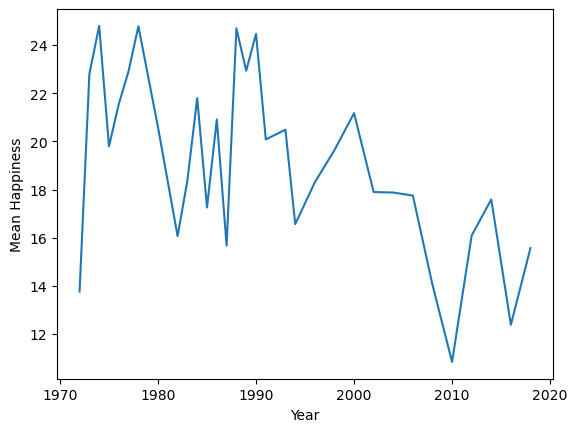

In [60]:
sns.lineplot(data = hap_by_year, x = "YEAR", y = "HAPPY_scaled")
plt.xlabel("Year")
plt.ylabel("Mean Happiness");

**What can we infer from this trend?**

#### Boolean indexing

Presumably pets make us happy. Let's see if happiness scales with the number of pets we have.

In [61]:
col_select = ["YEAR","AGE","NUMPETS","HAPPY_scaled"]
happy_sub = happy[col_select]
happy_sub.count()

YEAR            64814
AGE             64586
NUMPETS          1147
HAPPY_scaled    60054
dtype: int64

We only have 1147 records for number of pets. We should winnow the data so that we only have records that aren't NA. 

To start, we need a boolean array to index our DataFrame by.

In [62]:
# Which values in the NUMPETS column are NA?
happy["NUMPETS"].isna()

0         True
1         True
2         True
3         True
4         True
         ...  
64809     True
64810     True
64811    False
64812     True
64813     True
Name: NUMPETS, Length: 64814, dtype: bool

This is a start, but we don't want to return records that are NA (true), we want the opposite.

In [63]:
# Use ~ to invert a boolean array
~happy["NUMPETS"].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
64809    False
64810    False
64811     True
64812    False
64813    False
Name: NUMPETS, Length: 64814, dtype: bool

Now use this expression to index the DataFrame.

In [64]:
happy_sub = happy_sub[~happy_sub["NUMPETS"].isna()]
happy_sub

,YEAR,AGE,NUMPETS,HAPPY_scaled
62467,2018,74.0,0.0,100.0
62469,2018,63.0,0.0,100.0
62470,2018,71.0,1.0,0.0
62472,2018,59.0,1.0,0.0
62473,2018,43.0,0.0,0.0
...,...,...,...,...
64802,2018,25.0,0.0,-100.0
64803,2018,87.0,0.0,0.0
64804,2018,46.0,1.0,-100.0
64808,2018,19.0,2.0,0.0


Find the average happiness for each number of pets.

In [65]:
y = happy_sub.groupby("NUMPETS")["HAPPY_scaled"].mean()
y_sd = happy_sub.groupby("NUMPETS")["HAPPY_scaled"].std()

<ErrorbarContainer object of 3 artists>

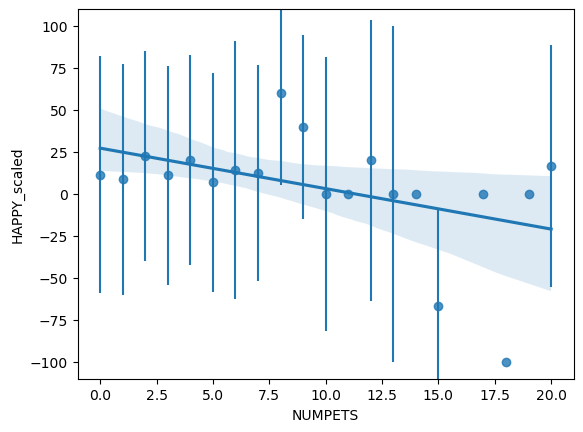

In [66]:
fig, ax = plt.subplots()
sns.regplot(x = y.index, y = y, ax = ax)
plt.ylim([-110,110])
ax.errorbar(y.index, y, yerr = y_sd, fmt = "none")

Maybe certain pets matter more?

In [67]:
happy.groupby(["CAT","DOG"]).mean("HAPPY").reset_index()[["CAT","DOG","HAPPY"]]

,CAT,DOG,HAPPY
0,0.0,0.0,1.875000
1,0.0,1.0,1.808864
2,1.0,0.0,2.031250
3,1.0,1.0,1.866197


Or age?

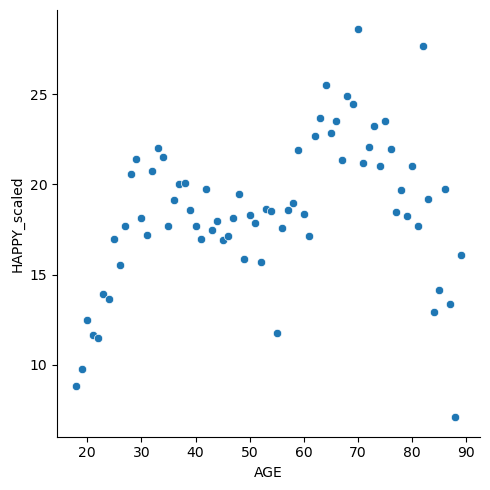

In [68]:
sns.relplot(happy.groupby("AGE")["HAPPY_scaled"].mean())